Load Datasets for Angry, Sad, Stress, Neutral

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
import numpy as np


In [13]:
IMG_SIZE = (48, 48)
BATCH_SIZE = 64
train_dir = "dataset/train"

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    shear_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    fill_mode='nearest',
    validation_split=0.2
)


train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale", 
    class_mode="categorical",
    subset="validation",
    shuffle=False
)


Found 14938 images belonging to 4 classes.
Found 3733 images belonging to 4 classes.


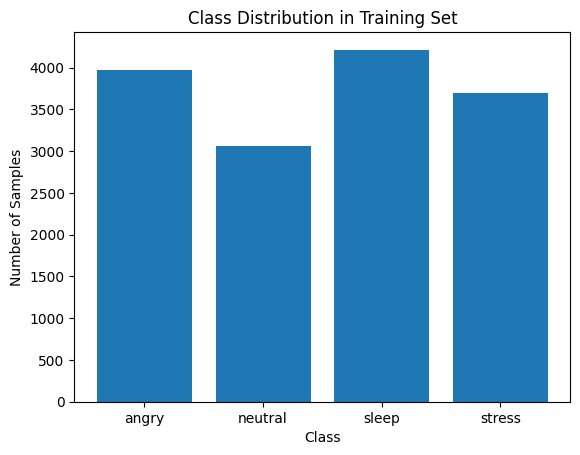

In [14]:
import collections
import matplotlib.pyplot as plt

train_counts = collections.Counter(train_generator.classes)
class_names = list(train_generator.class_indices.keys())
plt.bar(class_names, [train_counts[i] for i in range(len(class_names))])
plt.title("Class Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()


In [15]:
model = Sequential([
    Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(48, 48, 1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(512, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
class_labels = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_labels),
    y=class_labels
)
class_weights_dict = dict(enumerate(class_weights))
print(class_weights_dict)

{0: np.float64(0.9402064451158106), 1: np.float64(1.2200261352499184), 2: np.float64(0.8864229765013055), 3: np.float64(1.0115113759479957)}


In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)


In [19]:
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights_dict
)


Epoch 1/50


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


234/234 ━━━━━━━━━━━━━━━━━━━━ 60s 248ms/step - accuracy: 0.2752 - loss: 1.5830 - val_accuracy: 0.2049 - val_loss: 1.5743 - learning_rate: 5.0000e-04
Epoch 2/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 60s 255ms/step - accuracy: 0.2823 - loss: 1.3950 - val_accuracy: 0.2170 - val_loss: 1.4343 - learning_rate: 5.0000e-04
Epoch 3/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 60s 256ms/step - accuracy: 0.3159 - loss: 1.3678 - val_accuracy: 0.2590 - val_loss: 1.4098 - learning_rate: 5.0000e-04
Epoch 4/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 60s 257ms/step - accuracy: 0.3487 - loss: 1.3382 - val_accuracy: 0.3073 - val_loss: 1.4011 - learning_rate: 5.0000e-04
Epoch 5/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 59s 252ms/step - accuracy: 0.3792 - loss: 1.3028 - val_accuracy: 0.2306 - val_loss: 1.5081 - learning_rate: 5.0000e-04
Epoch 6/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 59s 254ms/step - accuracy: 0.4245 - loss: 1.2570 - val_accuracy: 0.3370 - val_loss: 1.3801 - learning_rate: 5.0000e-04
Epoch 7/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 59s 254ms/step - 

In [20]:
model.save("facial_emotion_model.h5")

In [21]:
import collections
print("Train class distribution:", collections.Counter(train_generator.classes))
print("Val class distribution:", collections.Counter(val_generator.classes))

Train class distribution: Counter({np.int32(2): 4213, np.int32(0): 3972, np.int32(3): 3692, np.int32(1): 3061})
Val class distribution: Counter({np.int32(2): 1053, np.int32(0): 993, np.int32(3): 922, np.int32(1): 765})


In [22]:
from sklearn.metrics import classification_report, confusion_matrix

Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)

print("Confusion Matrix")
print(confusion_matrix(val_generator.classes, y_pred))

target_names = list(train_generator.class_indices.keys())
print("\nClassification Report")
print(classification_report(val_generator.classes, y_pred, target_names=target_names))


59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step
Confusion Matrix
[[592 149 175  77]
 [ 71 513 142  39]
 [151 229 574  99]
 [120 110 197 495]]

Classification Report
              precision    recall  f1-score   support

       angry       0.63      0.60      0.61       993
     neutral       0.51      0.67      0.58       765
       sleep       0.53      0.55      0.54      1053
      stress       0.70      0.54      0.61       922

    accuracy                           0.58      3733
   macro avg       0.59      0.59      0.58      3733
weighted avg       0.59      0.58      0.58      3733

